In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
metro = pd.read_csv("C:/Users/300408947/Desktop/housing_project/data/raw/metro_zhvi.csv")
mortgage = pd.read_csv("C:/Users/300408947/Desktop/housing_project/data/raw/mortgage_rates.csv")

In [3]:
metro.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
0,102001,0,United States,country,NaN,121066.152956,121279.147130,121543.291267,122109.828593,122761.845131,...,358275.968224,357665.098303,357242.876410,357017.595555,357256.667089,357686.423395,358355.292319,359137.808336,359884.379965,360590.988249
1,394913,1,"New York, NY",msa,NY,216280.796610,217199.867965,218127.451578,220007.094908,221953.530668,...,686494.959066,687957.664142,689119.941396,689903.028184,691291.361808,693606.472034,696919.534309,700309.679669,703346.479016,706888.193139
2,753899,2,"Los Angeles, CA",msa,CA,221540.469091,222364.880724,223462.989157,225647.856057,228037.415487,...,947802.390588,943448.992297,940857.264784,939786.105392,940842.701541,943258.565513,946575.492297,950534.811318,953064.414891,954296.088135
3,394463,3,"Chicago, IL",msa,IL,151333.694136,151473.785052,151740.590668,152404.336737,153202.743421,...,327362.694469,327718.682483,328546.457616,329528.522924,330843.224170,332130.068337,333656.410070,335364.951509,336962.703562,338685.299108
4,394514,4,"Dallas, TX",msa,TX,128246.740882,128303.862429,128369.529494,128540.059965,128764.899721,...,370409.953287,368034.578505,366008.241036,364639.606059,363989.425471,363639.156361,363374.226561,363155.465003,362719.853605,362141.885524


In [4]:
metro.columns

Index(['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName',
       '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31',
       ...
       '2025-05-31', '2025-06-30', '2025-07-31', '2025-08-31', '2025-09-30',
       '2025-10-31', '2025-11-30', '2025-12-31', '2026-01-31', '2026-02-28'],
      dtype='str', length=319)

In [5]:
mortgage.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [6]:
mortgage.columns

Index(['observation_date', 'MORTGAGE30US'], dtype='str')

In [7]:
la_data = metro[metro["RegionName"] == "Los Angeles, CA"].copy()
la_data.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31,2025-11-30,2025-12-31,2026-01-31,2026-02-28
2,753899,2,"Los Angeles, CA",msa,CA,221540.469091,222364.880724,223462.989157,225647.856057,228037.415487,...,947802.390588,943448.992297,940857.264784,939786.105392,940842.701541,943258.565513,946575.492297,950534.811318,953064.414891,954296.088135


In [8]:
id_columns = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]

la_long = la_data.melt(
    id_vars=id_columns,
    var_name="Date",
    value_name="ZHVI"
)

la_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI
0,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,221540.469091
1,753899,2,"Los Angeles, CA",msa,CA,2000-02-29,222364.880724
2,753899,2,"Los Angeles, CA",msa,CA,2000-03-31,223462.989157
3,753899,2,"Los Angeles, CA",msa,CA,2000-04-30,225647.856057
4,753899,2,"Los Angeles, CA",msa,CA,2000-05-31,228037.415487


In [9]:
la_long["Date"] = pd.to_datetime(la_long["Date"], errors="coerce")
la_long = la_long.dropna(subset=["Date", "ZHVI"]).copy()
la_long = la_long.sort_values("Date")

la_long.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,Date,ZHVI
0,753899,2,"Los Angeles, CA",msa,CA,2000-01-31,221540.469091
1,753899,2,"Los Angeles, CA",msa,CA,2000-02-29,222364.880724
2,753899,2,"Los Angeles, CA",msa,CA,2000-03-31,223462.989157
3,753899,2,"Los Angeles, CA",msa,CA,2000-04-30,225647.856057
4,753899,2,"Los Angeles, CA",msa,CA,2000-05-31,228037.415487


In [10]:
print(la_long["Date"].min(), "to", la_long["Date"].max())
print(la_long.shape)

2000-01-31 00:00:00 to 2026-02-28 00:00:00
(314, 7)


In [11]:
mortgage["observation_date"] = pd.to_datetime(mortgage["observation_date"])
mortgage["MORTGAGE30US"] = pd.to_numeric(mortgage["MORTGAGE30US"], errors="coerce")
mortgage = mortgage.dropna().copy()

mortgage.head()

,observation_date,MORTGAGE30US
0,1971-04-02,7.33
1,1971-04-09,7.31
2,1971-04-16,7.31
3,1971-04-23,7.31
4,1971-04-30,7.29


In [12]:
mortgage["YearMonth"] = mortgage["observation_date"].dt.to_period("M")

mortgage_monthly = (
    mortgage.groupby("YearMonth")["MORTGAGE30US"]
    .mean()
    .reset_index()
)

mortgage_monthly["Date"] = mortgage_monthly["YearMonth"].dt.to_timestamp()

mortgage_monthly.head()

,YearMonth,MORTGAGE30US,Date
0,1971-04,7.3100,1971-04-01
1,1971-05,7.4250,1971-05-01
2,1971-06,7.5300,1971-06-01
3,1971-07,7.6040,1971-07-01
4,1971-08,7.6975,1971-08-01


In [13]:
la_long["YearMonth"] = la_long["Date"].dt.to_period("M")
la_long["Date"] = la_long["YearMonth"].dt.to_timestamp()

la_monthly = (
    la_long.groupby("Date")["ZHVI"]
    .mean()
    .reset_index()
)

la_monthly.head()

,Date,ZHVI
0,2000-01-01,221540.469091
1,2000-02-01,222364.880724
2,2000-03-01,223462.989157
3,2000-04-01,225647.856057
4,2000-05-01,228037.415487


In [14]:
merged_data = pd.merge(
    la_monthly,
    mortgage_monthly[["Date", "MORTGAGE30US"]],
    on="Date",
    how="inner"
)

merged_data = merged_data.sort_values("Date").reset_index(drop=True)

merged_data.head()

,Date,ZHVI,MORTGAGE30US
0,2000-01-01,221540.469091,8.2100
1,2000-02-01,222364.880724,8.3250
2,2000-03-01,223462.989157,8.2400
3,2000-04-01,225647.856057,8.1525
4,2000-05-01,228037.415487,8.5150


In [15]:
merged_data.shape

(314, 3)

In [17]:
merged_data.to_csv("C:/Users/300408947/Desktop/housing_project/data/merged_house_price_interest.csv", index=False)

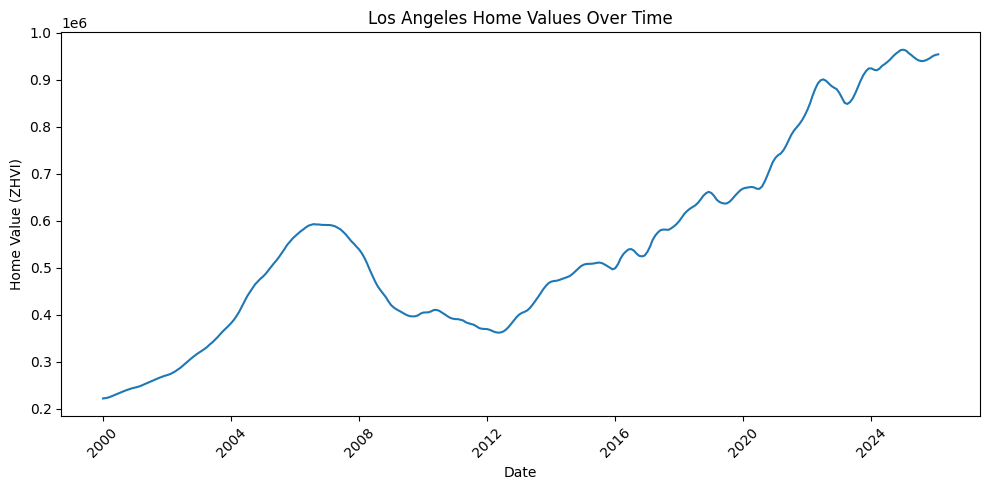

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(merged_data["Date"], merged_data["ZHVI"])
plt.xlabel("Date")
plt.ylabel("Home Value (ZHVI)")
plt.title("Los Angeles Home Values Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

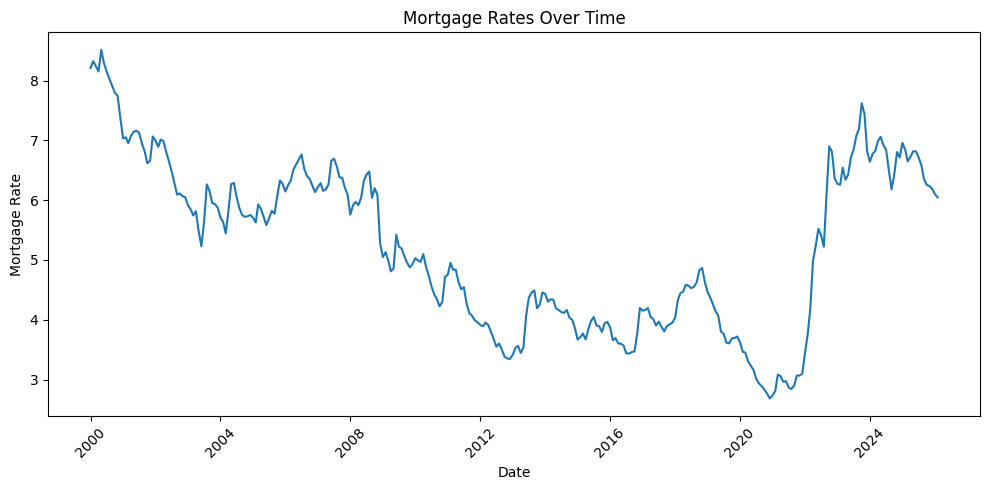

In [19]:
plt.figure(figsize=(10, 5))
plt.plot(merged_data["Date"], merged_data["MORTGAGE30US"])
plt.xlabel("Date")
plt.ylabel("Mortgage Rate")
plt.title("Mortgage Rates Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

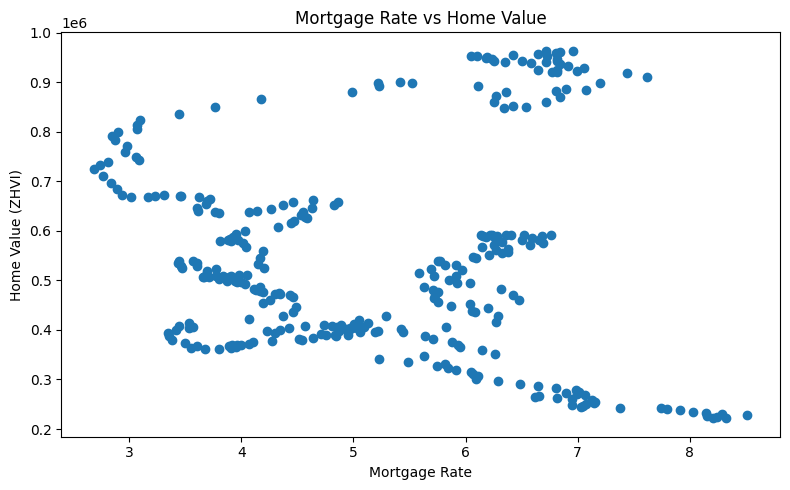

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(merged_data["MORTGAGE30US"], merged_data["ZHVI"])
plt.xlabel("Mortgage Rate")
plt.ylabel("Home Value (ZHVI)")
plt.title("Mortgage Rate vs Home Value")
plt.tight_layout()
plt.show()

In [21]:
merged_data["ZHVI_Lag1"] = merged_data["ZHVI"].shift(1)
merged_data["Rate_Lag1"] = merged_data["MORTGAGE30US"].shift(1)
merged_data["Target_Next_Month_ZHVI"] = merged_data["ZHVI"].shift(-1)

model_data = merged_data.dropna().copy()
model_data.head()

,Date,ZHVI,MORTGAGE30US,ZHVI_Lag1,Rate_Lag1,Target_Next_Month_ZHVI
1,2000-02-01,222364.880724,8.3250,221540.469091,8.2100,223462.989157
2,2000-03-01,223462.989157,8.2400,222364.880724,8.3250,225647.856057
3,2000-04-01,225647.856057,8.1525,223462.989157,8.2400,228037.415487
4,2000-05-01,228037.415487,8.5150,225647.856057,8.1525,230410.240511
5,2000-06-01,230410.240511,8.2880,228037.415487,8.5150,232842.624963


In [22]:
X = model_data[["ZHVI", "MORTGAGE30US", "ZHVI_Lag1", "Rate_Lag1"]]
y = model_data["Target_Next_Month_ZHVI"]

In [23]:
split_index = int(len(model_data) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (249, 4)
Testing shape: (63, 4)


In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

In [25]:
print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2:", r2_score(y_test, lr_preds))

Linear Regression Results
MAE: 2365.2686815449083
RMSE: 2856.677775954654
R2: 0.9982134085449827


In [26]:
rf_model = RandomForestRegressor(random_state=42, n_estimators=200)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

In [27]:
print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, rf_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_preds)))
print("R2:", r2_score(y_test, rf_preds))

Random Forest Results
MAE: 198713.24447971975
RMSE: 211887.271991738
R2: -8.829071161708153


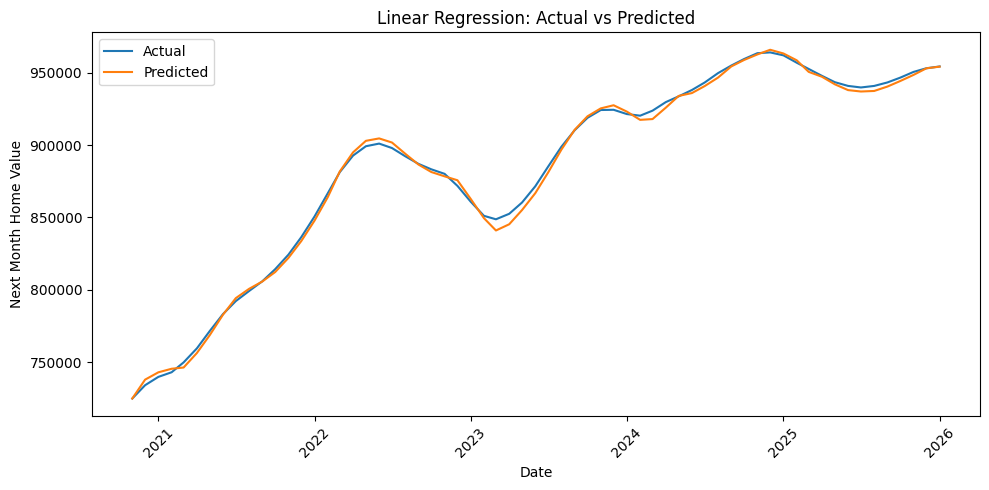

In [28]:
results_lr = pd.DataFrame({
    "Date": model_data["Date"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Predicted_LR": lr_preds
})

plt.figure(figsize=(10, 5))
plt.plot(results_lr["Date"], results_lr["Actual"], label="Actual")
plt.plot(results_lr["Date"], results_lr["Predicted_LR"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Next Month Home Value")
plt.title("Linear Regression: Actual vs Predicted")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

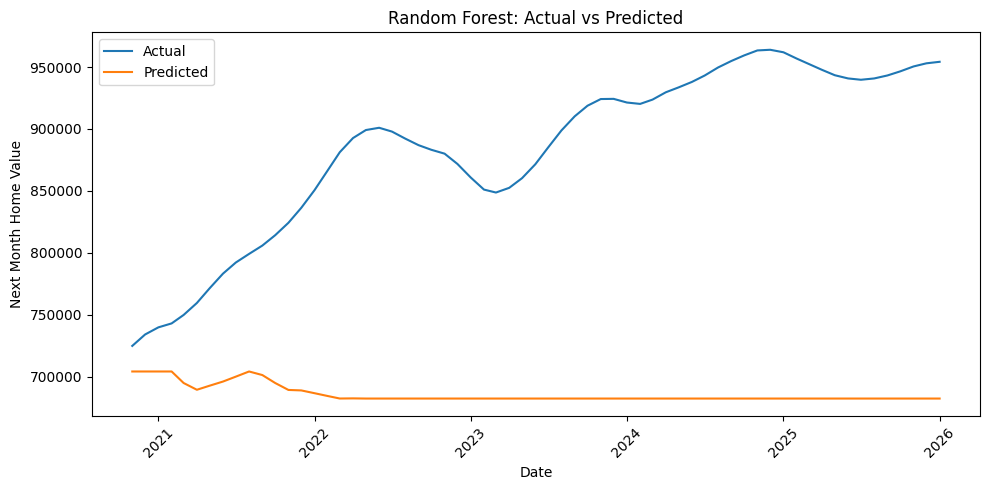

In [29]:
results_rf = pd.DataFrame({
    "Date": model_data["Date"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Predicted_RF": rf_preds
})

plt.figure(figsize=(10, 5))
plt.plot(results_rf["Date"], results_rf["Actual"], label="Actual")
plt.plot(results_rf["Date"], results_rf["Predicted_RF"], label="Predicted")
plt.xlabel("Date")
plt.ylabel("Next Month Home Value")
plt.title("Random Forest: Actual vs Predicted")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
model_data.to_csv("C:/Users/300408947/Desktop/housing_project/data/final_model_data.csv", index=False)

In [31]:
la_monthly.head()
merged_data.shape
print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (249, 4)
Testing shape: (63, 4)
